# VGG-16 Patch-Based AI Image Classifier

This notebook mirrors the original image-classification workflow, but it changes the experiment in a few important ways:

1. Uses the balanced `train_balanced`, `validation_balanced`, and `test_balanced` splits
2. Uses a `VGG-16` CNN
3. Trains from scratch by default so the model is encouraged to learn artifact-level cues instead of relying on generic ImageNet features
4. Uses a random `224x224` crop during training so the classifier sees local patches rather than the full image
5. Uses a centered `224x224` crop for validation and test so evaluation is stable across runs

If training from scratch converges too slowly, you can flip `use_pretrained=True` later and compare whether transfer learning helps or hurts artifact detection.


In [14]:
import os
import time

import matplotlib.pylab as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import wandb
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from torchvision.models import VGG16_Weights
from torchvision.transforms import functional as TF

# Use MPS on Apple Silicon when available, otherwise fall back to CPU.
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(device)


mps


In [15]:
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "requirements.txt").exists() and (PROJECT_ROOT.parent / "requirements.txt").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

OUTPUT_ROOT = PROJECT_ROOT / "output"
TRAIN_PATH = str(OUTPUT_ROOT / "train_balanced")
VAL_PATH = str(OUTPUT_ROOT / "validation_balanced")
TEST_PATH = str(OUTPUT_ROOT / "test_balanced")

WANDB_ENTITY = "william-em-watson-university-of-calgary-in-alberta"
WANDB_PROJECT = "ai-gen-image-detection"
WANDB_API_KEY = os.getenv("WANDB_API_KEY", "")


In [16]:
# Patch-based transforms
# Keep the crop size fixed at 224x224, but first upsample any image that is too small.
image_size = 224


class EnsureMinSize:
    def __init__(self, min_size=224, interpolation=transforms.InterpolationMode.BILINEAR):
        self.min_size = min_size
        self.interpolation = interpolation

    def __call__(self, image):
        width, height = image.size
        if width >= self.min_size and height >= self.min_size:
            return image

        scale = max(self.min_size / width, self.min_size / height)
        new_width = max(self.min_size, round(width * scale))
        new_height = max(self.min_size, round(height * scale))
        return TF.resize(image, (new_height, new_width), interpolation=self.interpolation)


# A simple symmetric normalization works well when training from scratch.
normalization = transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
ensure_min_size = EnsureMinSize(min_size=image_size)

train_transform = transforms.Compose([
    ensure_min_size,
    transforms.RandomCrop(image_size),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    normalization,
])

val_test_transform = transforms.Compose([
    ensure_min_size,
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    normalization,
])

train_dataset = ImageFolder(root=TRAIN_PATH, transform=train_transform)
val_dataset = ImageFolder(root=VAL_PATH, transform=val_test_transform)
test_dataset = ImageFolder(root=TEST_PATH, transform=val_test_transform)

batch_size = 16
num_workers = 0

trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
valloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
testloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)


In [17]:
class_names = train_dataset.classes
print(class_names)
print('Train set:', len(train_dataset))
print('Val set:', len(val_dataset))
print('Test set:', len(test_dataset))



['ai_generated', 'real']
Train set: 3800
Val set: 608
Test set: 856


In [18]:
train_iterator = iter(trainloader)
train_batch = next(train_iterator)

In [19]:
print(train_batch[0].size())
print(train_batch[1].size())

torch.Size([16, 3, 224, 224])
torch.Size([16])


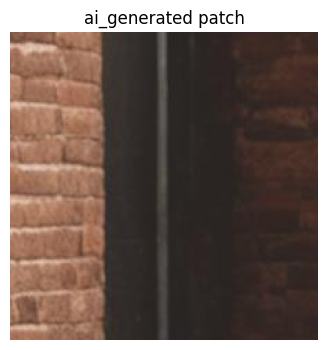

In [20]:
# Visualize one normalized training patch.
# We undo normalization here so the image displays correctly.
mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
std = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)

sample_image = train_batch[0][2].cpu() * std + mean
sample_image = sample_image.clamp(0, 1)

plt.figure(figsize=(4, 4))
plt.imshow(sample_image.permute(1, 2, 0).numpy())
plt.title(f"{class_names[train_batch[1][2].item()]} patch")
plt.axis('off')
plt.show()


In [21]:
class AiGenModel(nn.Module):
    def __init__(self, num_classes=2, use_pretrained=False, freeze_features=False):
        super().__init__()

        self.use_pretrained = use_pretrained
        self.freeze_features = freeze_features

        weights = VGG16_Weights.DEFAULT if use_pretrained else None
        self.feature_extractor = models.vgg16(weights=weights)

        if self.use_pretrained and self.freeze_features:
            for param in self.feature_extractor.features.parameters():
                param.requires_grad = False

        in_features = self.feature_extractor.classifier[-1].in_features
        self.feature_extractor.classifier[-1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.feature_extractor(x)


In [22]:
num_classes = len(class_names)
use_pretrained = False
freeze_features = False

# Starting from scratch aligns with the goal of learning AI-generation artifacts directly.
net = AiGenModel(
    num_classes=num_classes,
    use_pretrained=use_pretrained,
    freeze_features=freeze_features,
).to(device)
print(net)


AiGenModel(
  (feature_extractor): VGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=Tru

In [23]:
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-4
weight_decay = 1e-4

trainable_params = [param for param in net.parameters() if param.requires_grad]
optimizer = optim.AdamW(trainable_params, lr=learning_rate, weight_decay=weight_decay)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

train_crop_name = 'random_224x224'
eval_crop_name = 'center_224x224'
min_size_policy = 'resize_if_any_dimension_below_224'

if WANDB_API_KEY:
    wandb.login(key=WANDB_API_KEY)
else:
    print('WANDB_API_KEY is not set. Export it in your environment before training if you want W&B logging.')

wandb_config = {
    'train_path': TRAIN_PATH,
    'val_path': VAL_PATH,
    'test_path': TEST_PATH,
    'model_name': 'vgg16',
    'use_pretrained': use_pretrained,
    'freeze_features': freeze_features,
    'image_size': image_size,
    'min_size_policy': min_size_policy,
    'train_crop': train_crop_name,
    'eval_crop': eval_crop_name,
    'batch_size': batch_size,
    'num_workers': num_workers,
    'learning_rate': learning_rate,
    'weight_decay': weight_decay,
    'num_classes': num_classes,
    'device': str(device),
}

wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    config=wandb_config,
)

wandb.define_metric('epoch')
wandb.define_metric('train_loss', step_metric='epoch')
wandb.define_metric('train_acc', step_metric='epoch')
wandb.define_metric('val_loss', step_metric='epoch')
wandb.define_metric('val_acc', step_metric='epoch')
wandb.define_metric('learning_rate', step_metric='epoch')
wandb.define_metric('epoch_time_sec', step_metric='epoch')
wandb.watch(net, criterion, log='all', log_freq=50)


wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


In [24]:
# Tune nepochs and patience depending on how quickly validation loss plateaus.
nepochs = 10
PATH = './genai_vgg16_random_patch_best.pth'

wandb.config.update({'nepochs': nepochs}, allow_val_change=True)

best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(nepochs):
    epoch_start_time = time.perf_counter()
    net.train()
    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in trainloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = running_train_loss / len(train_dataset)
    train_acc = train_correct / train_total

    net.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in valloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = net(inputs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = running_val_loss / len(val_dataset)
    val_acc = val_correct / val_total
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    epoch_time_sec = time.perf_counter() - epoch_start_time

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    wandb.log({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'learning_rate': current_lr,
        'epoch_time_sec': epoch_time_sec,
    })

    print(
        f'Epoch {epoch + 1}/{nepochs} | '
        f'train_loss={train_loss:.4f} train_acc={train_acc:.4f} | '
        f'val_loss={val_loss:.4f} val_acc={val_acc:.4f}'
    )

    if val_loss < best_val_loss:
        print('Saving best model')
        torch.save(net.state_dict(), PATH)
        best_val_loss = val_loss
        wandb.run.summary['best_val_loss'] = best_val_loss
        wandb.run.summary['best_epoch'] = epoch + 1

print('Finished training')


Epoch 1/10 | train_loss=0.6941 train_acc=0.5082 | val_loss=0.6922 val_acc=0.5033
Saving best model


KeyboardInterrupt: 

In [ ]:
# Load the best model before evaluating on the test set.
net = AiGenModel(
    num_classes=len(class_names),
    use_pretrained=use_pretrained,
    freeze_features=freeze_features,
).to(device)
net.load_state_dict(torch.load(PATH, map_location=device))
net.eval()


In [ ]:
correct = 0
total = 0
test_loss = 0.0

test_start_time = time.perf_counter()
with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = net(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_inference_time_sec = time.perf_counter() - test_start_time
test_loss = test_loss / len(test_dataset)
test_accuracy = correct / total

test_metrics = {
    'test_loss': test_loss,
    'test_accuracy': test_accuracy,
    'test_accuracy_percent': 100 * test_accuracy,
    'test_inference_time_sec': test_inference_time_sec,
}
wandb.log(test_metrics)
for key, value in test_metrics.items():
    wandb.run.summary[key] = value

print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {100 * test_accuracy:.2f}%')
print(f'Test inference time: {test_inference_time_sec:.2f}s')



In [ ]:
# Optional: per-class accuracy helps us see whether one class is being ignored.
class_correct = {name: 0 for name in class_names}
class_total = {name: 0 for name in class_names}

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)

        for label, pred in zip(labels, predicted):
            class_name = class_names[label.item()]
            class_total[class_name] += 1
            if label.item() == pred.item():
                class_correct[class_name] += 1

for class_name in class_names:
    accuracy = class_correct[class_name] / max(class_total[class_name], 1)
    print(f'{class_name}: {100 * accuracy:.2f}% ({class_correct[class_name]}/{class_total[class_name]})')
    wandb.log({f'test_accuracy_{class_name}': accuracy})
    wandb.run.summary[f'test_accuracy_{class_name}'] = accuracy



In [ ]:
# Optional: visualize training curves.
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='train')
plt.plot(history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='train')
plt.plot(history['val_acc'], label='val')
plt.title('Accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# W&B already turns the logged epoch metrics into charts automatically.



In [ ]:
# Optional: plot the test-set confusion matrix.
confusion_matrix = torch.zeros((len(class_names), len(class_names)), dtype=torch.int64)

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)

        for label, pred in zip(labels.view(-1), predicted.view(-1)):
            confusion_matrix[label.item(), pred.item()] += 1

cm = confusion_matrix.cpu().numpy()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
fig.colorbar(im, ax=ax)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Test Confusion Matrix')

threshold = cm.max() / 2 if cm.size else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center',
            color='white' if cm[i, j] > threshold else 'black',
        )

plt.tight_layout()
plt.show()

wandb.finish()
